[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Generalization: the Goal of Machine Learning

**Two students prepping for a final by working through the course materials:**

- **Ellie** memorizes past questions and material → aces *recycled* questions, freezes on *new* ones.
- **Irene** picks up patterns, ~90% accurate → holds up on *fresh* questions too.

Who is likely to do better on the exam?

Our goal as ML scientists is to **discover patterns that *generalize***.  Not memorize the data.
We care about tomorrow's stock price, the *next* patient's diagnosis — not yesterday's.

> **The central question:** how do we know that our model found a real pattern, and didn't just memorize?


## Training Error vs. Generalization Error

**IID assumption:** train and test data drawn *independently* from the *same* distribution.

- **Training error** $R_\textrm{emp}$ — a *statistic* computed on the training set:
$$R_\textrm{emp} = \frac{1}{n} \sum_{i=1}^n l(\mathbf{x}^{(i)}, y^{(i)}, f(\mathbf{x}^{(i)}))$$

- **Generalization error** $R$ — an *expectation* over the true distribution:
$$R = E_{(\mathbf{x}, y) \sim P}\,[l(\mathbf{x}, y, f(\mathbf{x}))]$$

We can **never compute $R$** → estimate it on a held-out **test set**.


## Model Complexity

- Simple model + lots of data → training and generalization error stay close.
- Complex model + few examples → training error goes to zero, but the **gap grows**.

A model expressive enough to fit *arbitrary (even random) labels* tells us **nothing** from training error alone.

**Key caveat (especially for deep nets):** low training error doesn't imply *low* generalization error. But it doesn't imply *high* either. It just isn't, by itself, a certificate. → rely on **validation error**.

Complexity isn't only parameter count — the **range of values** weights can take matters too (weight decay, next notebook).


## Demo: Polynomial Curve Fitting

Fit a degree-$d$ polynomial to a single feature $x$:
$$\hat{y}(x) = w_0 + w_1 x + w_2 x^2 + \ldots + w_d x^d$$

This is just **linear regression on powers of $x$**. Watch what happens as $d$ grows:


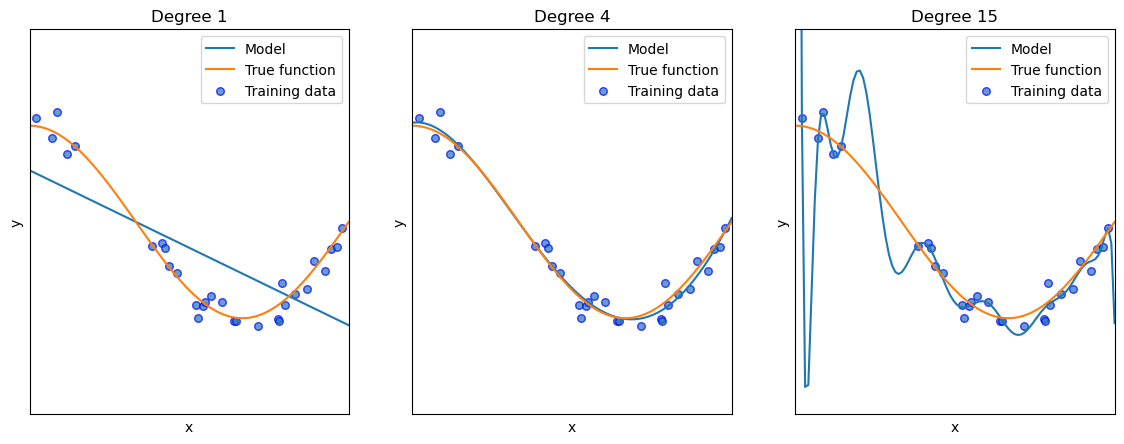

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    pipeline = Pipeline([("pf", PolynomialFeatures(degree=degrees[i], include_bias=False)),
                         ("lr", LinearRegression())])
    pipeline.fit(X[:, np.newaxis], y)
    Xs = np.linspace(0, 1, 100)
    plt.plot(Xs, pipeline.predict(Xs[:, np.newaxis]), label="Model")
    plt.plot(Xs, true_fun(Xs), label="True function")
    plt.scatter(X, y, edgecolor='b', s=30, alpha=0.7, label="Training data")
    plt.xlim((0, 1)); plt.ylim((-2, 2))
    plt.xlabel("x"); plt.ylabel("y")
    plt.legend(loc="best")
    plt.title("Degree {}".format(degrees[i]))

**Degree 1** underfits, **degree 4** is about right, **degree 15** fits the points but goes wild between them.  A clear sign of **overfitting**.

Now plot train and validation error across degrees:


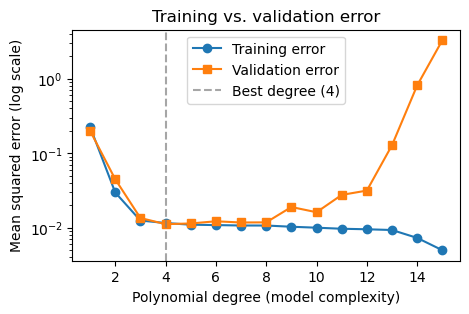

In [3]:
from sklearn.metrics import mean_squared_error

X_val = np.sort(np.random.rand(1000))
y_val = true_fun(X_val) + np.random.randn(1000) * 0.1

all_degrees = range(1, 16)
train_err, val_err = [], []
for d in all_degrees:
    pipeline = Pipeline([("pf", PolynomialFeatures(degree=d, include_bias=False)),
                         ("lr", LinearRegression())])
    pipeline.fit(X[:, np.newaxis], y)
    train_err.append(mean_squared_error(y, pipeline.predict(X[:, np.newaxis])))
    val_err.append(mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis])))

best_degree = list(all_degrees)[int(np.argmin(val_err))]

plt.figure(figsize=(5, 3))
plt.plot(list(all_degrees), train_err, 'o-', label="Training error")
plt.plot(list(all_degrees), val_err, 's-', label="Validation error")
plt.axvline(best_degree, color='gray', linestyle='--', alpha=0.7,
            label=f"Best degree ({best_degree})")
plt.yscale("log")
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("Mean squared error (log scale)")
plt.title("Training vs. validation error")
plt.legend(loc="best");

**Training error** falls monotonically. **Validation error** is U-shaped — minimized at the sweet spot, then blows up. This is the classic complexity-vs-error picture:

In [ ]:
def capacity_vs_error_figure():
    """Training and generalization error as model complexity grows."""
    from matplotlib.patches import FancyArrowPatch

    blue, red, grey = '#2c6d9e', '#c1440e', '0.45'
    c = np.linspace(0.02, 1.0, 500)

    train = 0.16 + 0.80 * np.exp(-4.4 * c)      # falls monotonically, forever
    gap = 0.06 * (np.exp(2.4 * c) - 1.0)        # the price of extra capacity
    gen = train + gap
    k = int(np.argmin(gen))
    best = c[k]

    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    ax.axvspan(c[0], best, color='#eef3f8', zorder=0)
    ax.axvspan(best, c[-1], color='#f6f0f4', zorder=0)
    ax.plot(c, gen, color=red, linewidth=1.9, zorder=3,
            label='generalization error')
    ax.plot(c, train, color=blue, linewidth=1.9, zorder=3,
            label='training error')

    ax.axvline(best, color=grey, linewidth=0.9, linestyle=(0, (4, 3)), zorder=2)
    ax.plot([best], [gen[k]], marker='o', markersize=5, color=red, zorder=4)

    top = 1.06
    ax.text(best / 2, top, 'underfitting', ha='center', va='top', fontsize=10,
            color='0.3', fontweight='bold')
    ax.text((best + 1.0) / 2, top, 'overfitting', ha='center', va='top',
            fontsize=10, color='0.3', fontweight='bold')

    ax.annotate('best model', xy=(best, gen[k]), xytext=(best - 0.17, 0.68),
                fontsize=9, color='0.25', ha='center', va='center',
                arrowprops=dict(arrowstyle='-', color='0.55', linewidth=0.8))

    # the gap, measured at the right-hand edge
    j = -22
    ax.add_patch(FancyArrowPatch((c[j], train[j]), (c[j], gen[j]),
                                 arrowstyle='<|-|>', mutation_scale=7,
                                 linewidth=0.9, color='0.35', shrinkA=0,
                                 shrinkB=0, zorder=4))
    ax.text(c[j] - 0.02, (train[j] + gen[j]) / 2, 'generalization gap',
            ha='right', va='center', fontsize=8, color='0.3', zorder=5,
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='none', alpha=0.85))

    ax.set_xlabel('model complexity')
    ax.set_ylabel('error')
    ax.set_xlim(c[0], c[-1])
    ax.set_ylim(0, 1.10)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.5')
    ax.legend(loc='lower left', bbox_to_anchor=(0.03, 0.04), frameon=False,
              fontsize=9)
    fig.tight_layout()

capacity_vs_error_figure()

**Overfitting in a nutshell:** model matches the training set too closely, learns the *noise* not the *signal*, fails on new data.

## Underfitting vs. Overfitting

| | Training error | Validation error | Diagnosis |
|---|---|---|---|
| **Underfitting** | high | high (small gap) | model too simple → add capacity |
| **Good fit** | low | low | the sweet spot |
| **Overfitting** | low | high (large gap) | model too flexible, fits noise |

We ultimately care about **driving generalization error down** — the gap matters only insofar as it gets in the way.


## Two More Levers

**Dataset size**
- Fewer samples → more (and more severe) overfitting.
- More data → generalization error typically drops; more data almost never hurts.
- Deep learning often beats linear models only with *many thousands* of examples.

**Model selection**
- Never tune on the **test set** — if you overfit it, you'll never know.
- Can't select on training data alone either → use a **validation set**.
- Standard practice: split data **three ways** (train / validation / test).


## Summary and a few rules of thumb

1. Use **validation sets** for model selection.
2. More complex models usually need **more data**.
3. Model complexity is determined by how expressive the model is.  Determined by **#parameters**, **architecture**, *and* the **range of weight values**.
4. All else being equal, **more data → better generalization**.
5. This all rests on the **IID assumption** — break it (distribution shift) and the guarantees go away.

**Next:** avoiding overfitting with **regularization** → keep the flexibility, lose the overfitting.

## Exercises

1. Give an example of a situation where a classifier produces **zero training error**.
2. Your manager hands you a hard dataset where your algorithm underperforms. How would you justify needing **more data**? *Hint: you can't add data, but you can remove some.*
